Jupiter


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.6 MB/s eta 0:00:00


In [ ]:
from astroquery.jplhorizons import Horizons
import pandas as pd
import matplotlib.pyplot as plt

# Jupiter = 599
# Earth center = 500@399
obj = Horizons(
    id="599",
    location="500@399",
    epochs={"start": "2026-01-01", "stop": "2026-12-31", "step": "1d"}
)

vectors = obj.vectors()

data = vectors.to_pandas()

print(data.head())

      targetname  datetime_jd                    datetime_str         x  \
0  Jupiter (599)    2461041.5  A.D. 2026-Jan-01 00:00:00.0000 -1.519722   
1  Jupiter (599)    2461042.5  A.D. 2026-Jan-02 00:00:00.0000 -1.509774   
2  Jupiter (599)    2461043.5  A.D. 2026-Jan-03 00:00:00.0000 -1.499883   
3  Jupiter (599)    2461044.5  A.D. 2026-Jan-04 00:00:00.0000 -1.490052   
4  Jupiter (599)    2461045.5  A.D. 2026-Jan-05 00:00:00.0000 -1.480288   

          y         z        vx        vy        vz  lighttime     range  \
0  3.961123  0.017486  0.009974  0.001014  0.000170   0.024504  4.242683   
1  3.962282  0.017656  0.009921  0.001304  0.000170   0.024489  4.240214   
2  3.963730  0.017826  0.009862  0.001591  0.000170   0.024477  4.238056   
3  3.965465  0.017996  0.009798  0.001879  0.000170   0.024466  4.236211   
4  3.967485  0.018165  0.009730  0.002163  0.000169   0.024457  4.234681   

   range_rate  
0   -0.002625  
1   -0.002313  
2   -0.002002  
3   -0.001687  
4   -0.00137

In [ ]:
AU_IN_METERS = 1.495978707e11

data["distance_m"] = data["range"] * AU_IN_METERS

print(data[["datetime_str", "range", "distance_m"]].head())

                     datetime_str     range    distance_m
0  A.D. 2026-Jan-01 00:00:00.0000  4.242683  6.346964e+11
1  A.D. 2026-Jan-02 00:00:00.0000  4.240214  6.343269e+11
2  A.D. 2026-Jan-03 00:00:00.0000  4.238056  6.340041e+11
3  A.D. 2026-Jan-04 00:00:00.0000  4.236211  6.337282e+11
4  A.D. 2026-Jan-05 00:00:00.0000  4.234681  6.334992e+11


In [ ]:
G = 6.67430e-11
M_JUPITER = 1.898e27

data["gravity"] = G * M_JUPITER / data["distance_m"]**2

print(data[["datetime_str", "distance_m", "gravity"]].head())

                     datetime_str    distance_m       gravity
0  A.D. 2026-Jan-01 00:00:00.0000  6.346964e+11  3.144633e-07
1  A.D. 2026-Jan-02 00:00:00.0000  6.343269e+11  3.148297e-07
2  A.D. 2026-Jan-03 00:00:00.0000  6.340041e+11  3.151503e-07
3  A.D. 2026-Jan-04 00:00:00.0000  6.337282e+11  3.154248e-07
4  A.D. 2026-Jan-05 00:00:00.0000  6.334992e+11  3.156529e-07


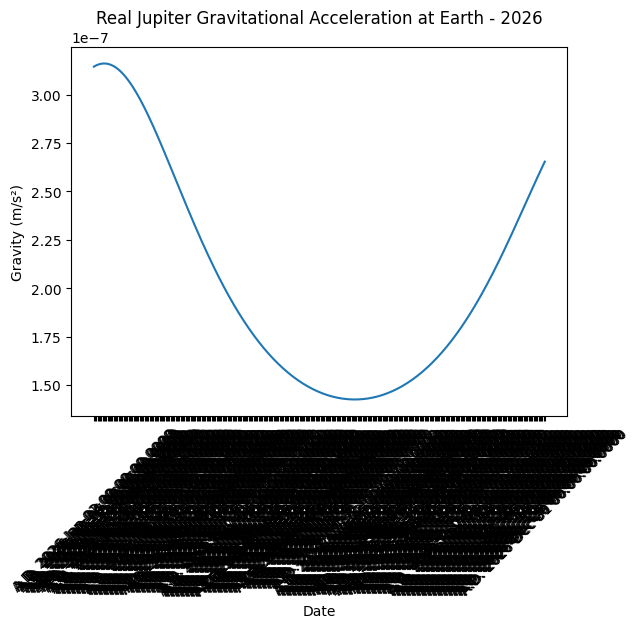

In [ ]:
plt.plot(data["datetime_str"], data["gravity"])
plt.title("Real Jupiter Gravitational Acceleration at Earth - 2026")
plt.xlabel("Date")
plt.ylabel("Gravity (m/s²)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Constants
G = 6.67430e-11
M_JUPITER = 1.898e27
EARTH_RADIUS = 6.371e6

# 1. Jupiter gravitational acceleration
data["gravity"] = G * M_JUPITER / data["distance_m"]**2

# 2. Jupiter tidal acceleration approximation
data["tidal_acceleration"] = 2 * G * M_JUPITER * EARTH_RADIUS / data["distance_m"]**3

# 3. Tidal gradient approximation
data["tidal_gradient"] = 2 * G * M_JUPITER / data["distance_m"]**3

# 4. First derivatives
data["distance_change"] = data["distance_m"].diff()
data["gravity_change"] = data["gravity"].diff()
data["tidal_change"] = data["tidal_acceleration"].diff()

# 5. Second derivatives
data["distance_second_change"] = data["distance_change"].diff()
data["gravity_second_change"] = data["gravity_change"].diff()
data["tidal_second_change"] = data["tidal_change"].diff()

# 6. Show important columns
print(data[[
    "datetime_str",
    "distance_m",
    "gravity",
    "tidal_acceleration",
    "tidal_gradient",
    "distance_change",
    "gravity_change",
    "tidal_change"
]].head())

                     datetime_str    distance_m       gravity  \
0  A.D. 2026-Jan-01 00:00:00.0000  6.346964e+11  3.144633e-07   
1  A.D. 2026-Jan-02 00:00:00.0000  6.343269e+11  3.148297e-07   
2  A.D. 2026-Jan-03 00:00:00.0000  6.340041e+11  3.151503e-07   
3  A.D. 2026-Jan-04 00:00:00.0000  6.337282e+11  3.154248e-07   
4  A.D. 2026-Jan-05 00:00:00.0000  6.334992e+11  3.156529e-07   

   tidal_acceleration  tidal_gradient  distance_change  gravity_change  \
0        6.313083e-12    9.909093e-19              NaN             NaN   
1        6.324120e-12    9.926417e-19    -3.694473e+08    3.664086e-10   
2        6.333784e-12    9.941586e-19    -3.227827e+08    3.206523e-10   
3        6.342061e-12    9.954577e-19    -2.759164e+08    2.744838e-10   
4        6.348940e-12    9.965374e-19    -2.289733e+08    2.280568e-10   

   tidal_change  
0           NaN  
1  1.103710e-14  
2  9.664082e-15  
3  8.276525e-15  
4  6.879348e-15  


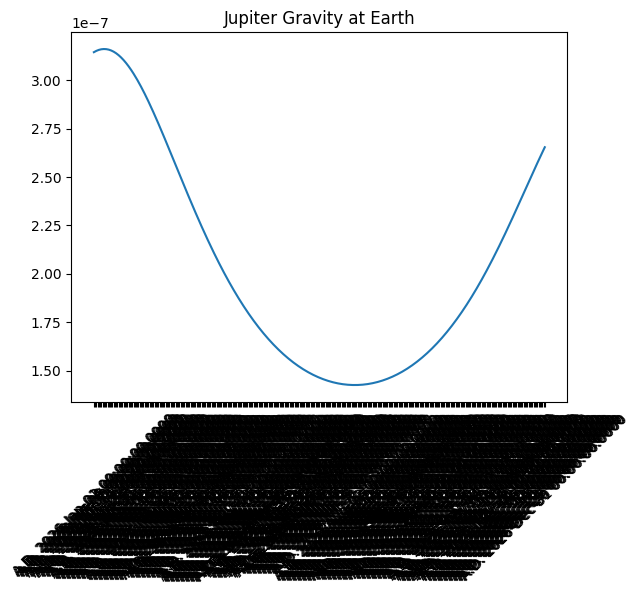

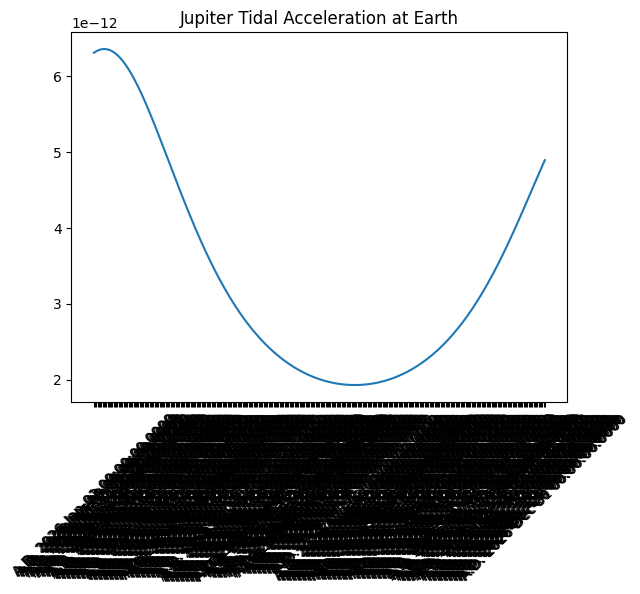

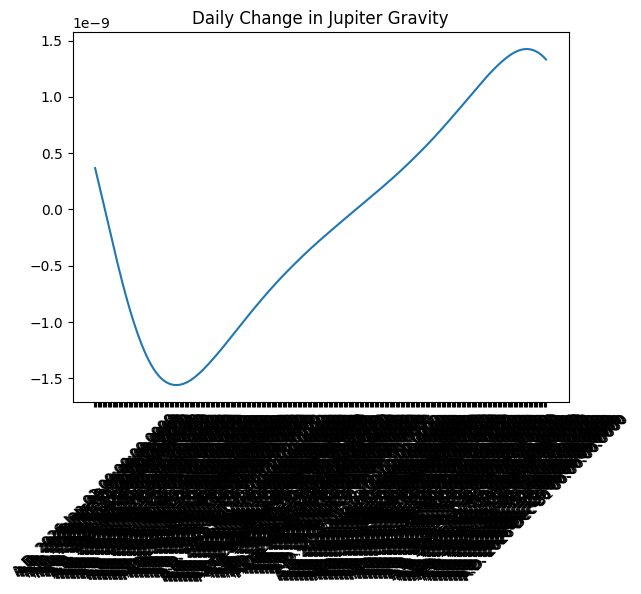

In [ ]:
plt.plot(data["datetime_str"], data["gravity"])
plt.title("Jupiter Gravity at Earth")
plt.xticks(rotation=45)
plt.show()

plt.plot(data["datetime_str"], data["tidal_acceleration"])
plt.title("Jupiter Tidal Acceleration at Earth")
plt.xticks(rotation=45)
plt.show()

plt.plot(data["datetime_str"], data["gravity_change"])
plt.title("Daily Change in Jupiter Gravity")
plt.xticks(rotation=45)
plt.show()

In [ ]:
data.to_csv("stage1_jupiter_signal_2026.csv", index=False)

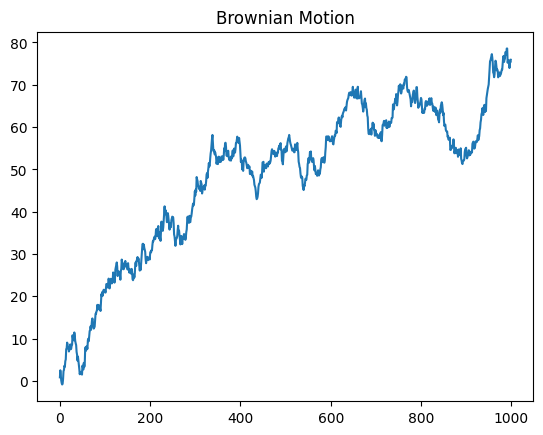

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

steps = 1000

motion = np.random.normal(0,1,steps)

position = np.cumsum(motion)

plt.plot(position)
plt.title("Brownian Motion")
plt.show()

In [ ]:
np.random.normal(0,1,steps)

array([ 2.23257723e-01, -5.59835027e-01,  8.47319098e-01, -4.01409882e-01,
       -1.85974388e-01,  1.78451213e+00, -2.14306766e+00, -4.55916383e-01,
        1.84653560e-01, -1.52303116e+00,  1.25819914e+00,  6.22087372e-01,
       -1.08364391e+00, -9.26633946e-01,  6.37177857e-01, -1.03262600e+00,
       -2.39985913e-01,  3.63069526e-01,  1.23565450e+00, -1.17375332e+00,
       -8.81821062e-02, -1.21644430e+00, -8.67666114e-01, -8.45073895e-01,
        1.19731683e+00,  1.68587774e+00, -1.18763434e+00, -5.41015697e-01,
        5.90565581e-01,  1.57282591e+00,  1.40854463e+00, -7.56493600e-02,
        1.03974942e+00,  2.67111023e-01, -9.96756722e-01,  2.41989000e-01,
       -6.53532057e-01,  2.94478372e-01, -1.93235683e+00, -5.50125814e-01,
        2.44051416e+00, -1.62687323e+00,  9.82370881e-01, -1.51062304e+00,
       -1.79806947e-01,  3.47711211e-01,  1.31526079e+00, -2.15043073e+00,
        6.26896712e-01,  1.80120837e+00, -8.03430140e-01,  1.63886039e-01,
       -5.29072787e-01, -

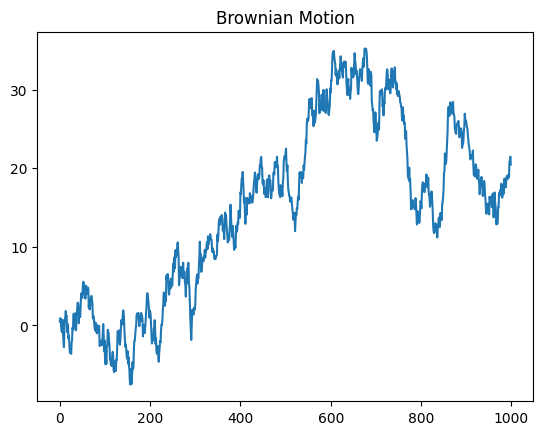

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

steps = 1000

motion = np.random.normal(0, 1, steps)

position = np.cumsum(motion)

plt.plot(position)
plt.title("Brownian Motion")
plt.show()

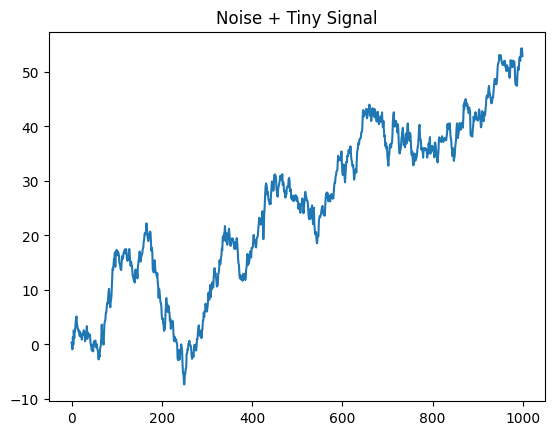

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

steps = 1000

noise = np.random.normal(0,1,steps)

signal = 0.05 * np.sin(np.linspace(0,20,steps))

motion = noise + signal

position = np.cumsum(motion)

plt.plot(position)
plt.title("Noise + Tiny Signal")
plt.show()

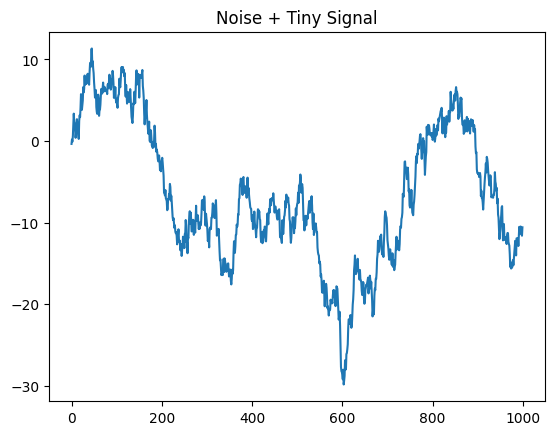

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

steps = 1000

noise = np.random.normal(0,1,steps)

signal = 0.05 * np.sin(np.linspace(0,20,steps))

motion = noise + signal

position = np.cumsum(motion)

plt.plot(position)
plt.title("Noise + Tiny Signal")
plt.show()

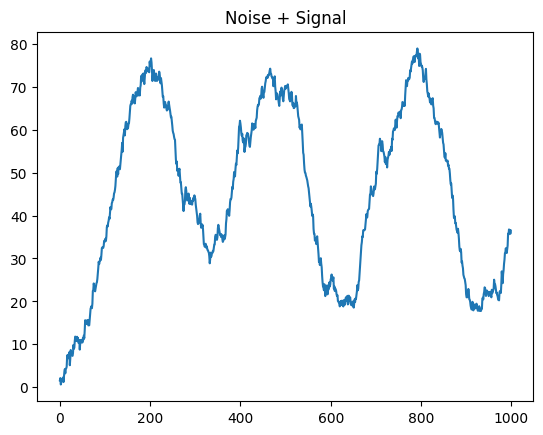

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

steps = 1000

noise = np.random.normal(0,1,steps)

signal = 0.5 * np.sin(np.linspace(0,20,steps))

motion = noise + signal

position = np.cumsum(motion)

plt.plot(position)
plt.title("Noise + Signal")
plt.show()

        gravity     noise  gravity_plus_noise
0  3.144633e-07  1.172875            1.172875
1  3.148297e-07  0.298380            0.298380
2  3.151503e-07 -0.563633           -0.563633
3  3.154248e-07  0.681133            0.681133
4  3.156529e-07  2.093214            2.093214


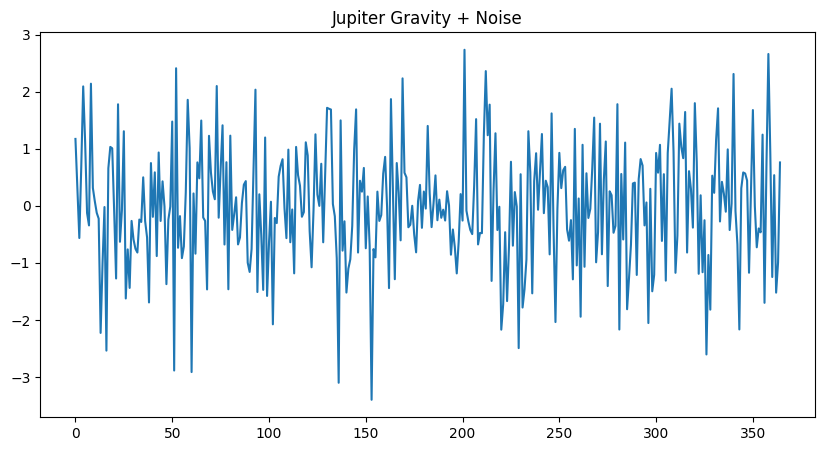

In [ ]:
data["noise"] = np.random.normal(0, 1, len(data))
data["gravity_plus_noise"] = data["gravity"] + data["noise"]

print(data[["gravity", "noise", "gravity_plus_noise"]].head())

plt.figure(figsize=(10,5))
plt.plot(data["gravity_plus_noise"])
plt.title("Jupiter Gravity + Noise")
plt.show()

In [ ]:
correlation = np.corrcoef(data["gravity"], data["gravity_plus_noise"])

print(correlation)

[[1.         0.00798825]
 [0.00798825 1.        ]]


In [ ]:
data["noise"] = np.random.normal(0, 0.0000001, len(data))
data["gravity_plus_noise"] = data["gravity"] + data["noise"]
correlation = np.corrcoef(
    data["gravity"],
    data["gravity_plus_noise"]
)

print(correlation[0,1])

0.5079153556427617


In [ ]:
data["noise"] = np.random.normal(0, 0.00000001, len(data))

data["gravity_plus_noise"] = data["gravity"] + data["noise"]

correlation = np.corrcoef(
    data["gravity"],
    data["gravity_plus_noise"]
)

print("Correlation:", correlation[0,1])

print(data[["gravity","noise","gravity_plus_noise"]].head())

Correlation: 0.9855611813330433
        gravity         noise  gravity_plus_noise
0  3.144633e-07  4.828656e-10        3.149461e-07
1  3.148297e-07  1.168649e-08        3.265162e-07
2  3.151503e-07  2.351981e-08        3.386701e-07
3  3.154248e-07 -8.331835e-09        3.070930e-07
4  3.156529e-07  7.956393e-10        3.164485e-07


In [ ]:
data["noise"] = np.random.normal(0, 0.0000003, len(data))

data["gravity_plus_noise"] = data["gravity"] + data["noise"]

correlation = np.corrcoef(
    data["gravity"],
    data["gravity_plus_noise"]
)

print("Correlation:", correlation[0,1])
print(data[["gravity", "noise", "gravity_plus_noise"]].head())

Correlation: 0.19029755630248368
        gravity         noise  gravity_plus_noise
0  3.144633e-07  1.974936e-07        5.119568e-07
1  3.148297e-07  2.666120e-07        5.814416e-07
2  3.151503e-07  2.967004e-07        6.118507e-07
3  3.154248e-07 -2.438508e-07        7.157405e-08
4  3.156529e-07  3.602600e-07        6.759128e-07


In [ ]:
mass = 1e-12
gravity = 3e-7

force = mass * gravity

print(force)

3e-19


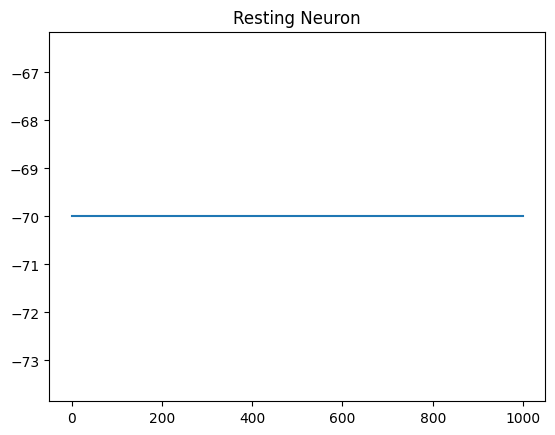

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

time = np.arange(1000)

voltage = np.ones(1000) * -70

plt.plot(voltage)
plt.title("Resting Neuron")
plt.show()

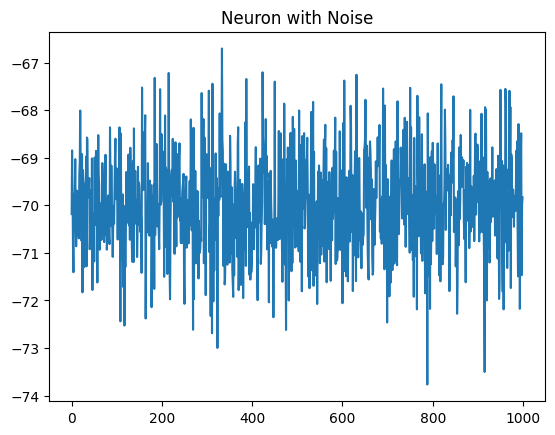

In [ ]:
voltage = np.ones(1000) * -70

noise = np.random.normal(
    0,
    1,
    1000
)

voltage = voltage + noise

plt.plot(voltage)
plt.title("Neuron with Noise")
plt.show()

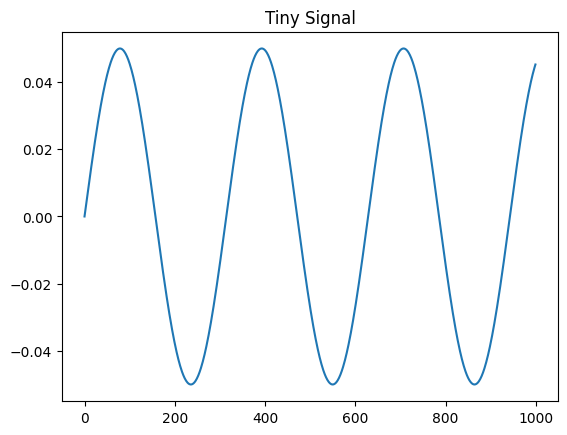

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

time = np.arange(1000)

signal = 0.05 * np.sin(time / 50)

plt.plot(signal)
plt.title("Tiny Signal")
plt.show()

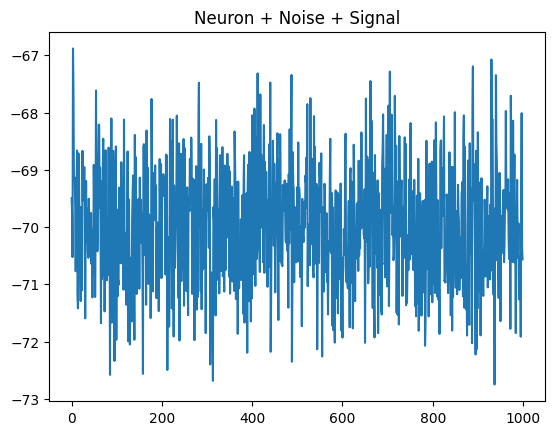

In [ ]:
voltage = np.ones(1000) * -70

noise = np.random.normal(0,1,1000)

signal = 0.05 * np.sin(time/50)

voltage = voltage + noise + signal

plt.plot(voltage)
plt.title("Neuron + Noise + Signal")
plt.show()

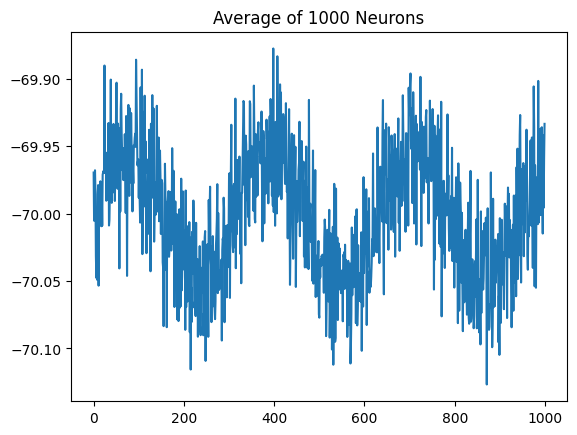

In [ ]:
neurons = []

for i in range(1000):

    noise = np.random.normal(0, 1, 1000)

    neuron = -70 + noise + signal

    neurons.append(neuron)

average_neuron = np.mean(neurons, axis=0)

plt.plot(average_neuron)
plt.title("Average of 1000 Neurons")
plt.show()

In [ ]:
correlation = np.corrcoef(signal, average_neuron)

print(correlation[0,1])

0.7238285734145218


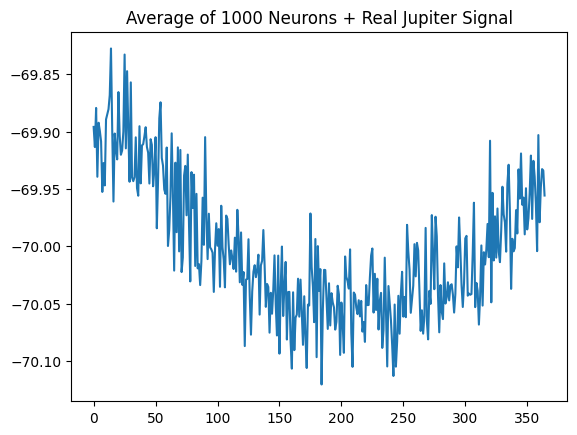

Correlation: 0.8542506984859282


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get Jupiter gravity from your dataframe
jupiter_signal = data["gravity"].values

# Normalize it
jupiter_signal = (jupiter_signal - np.mean(jupiter_signal)) / np.std(jupiter_signal)

# Make it a tiny voltage-like signal
jupiter_signal = 0.05 * jupiter_signal

# Make 1000 noisy neurons with same Jupiter signal
neurons = []

for i in range(1000):
    noise = np.random.normal(0, 1, len(jupiter_signal))
    neuron = -70 + noise + jupiter_signal
    neurons.append(neuron)

average_neuron = np.mean(neurons, axis=0)

plt.plot(average_neuron)
plt.title("Average of 1000 Neurons + Real Jupiter Signal")
plt.show()

correlation = np.corrcoef(jupiter_signal, average_neuron)

print("Correlation:", correlation[0,1])

In [ ]:
correlation = np.corrcoef(jupiter_signal, average_neuron)

print(correlation[0,1])

0.8542506984859282
